In [1]:
from lics_unwrap import *
import os
import numpy

ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatia

setting pyproj data directory


/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: un

In [6]:
pair='20240330_20240411'
# pair='20200906_20210615'
workdir='/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/sbois/post-3-060825/'
mli='116A_05582_141515/GEOCml10mask/slc.mli.par'
cc_file=f'116A_05582_141515/GEOC/{pair}/{pair}.geo.cc.tif'
full_path=os.path.join(workdir, cc_file)
# mli_par=os.path.join(workdir, mli)
# # Initialize variables
# range_samples = None
# azimuth_lines = None

# # Read the file and extract values
# with open(mli_par, 'r') as f:
#     for line in f:
#         if 'range_samples' in line:
#             range_samples = int(line.split(':')[1])
#         elif 'azimuth_lines' in line:
#             azimuth_lines = int(line.split(':')[1])

# print(f"range_samples: {range_samples}")
# print(f"azimuth_lines: {azimuth_lines}")
# Load as float32 and reshape
cc=load_tif2xr(full_path)
cc.values=cc.values/255
cc_masked = cc.where(cc >= 0.2)

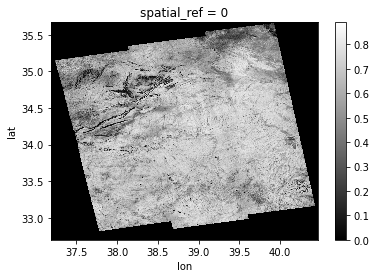

In [4]:
cc.plot(cmap='gray')

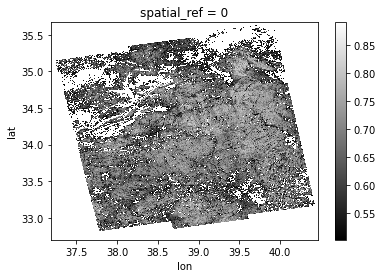

In [8]:
cc_masked = cc.where(cc >= 0.5)
cc_masked.plot(cmap='gray')

In [12]:
frame='014A_05232_242525'
frames = [014A_04920_161613  021D_04972_131213  043A_05008_161514  050D_05246_131313  087A_05101_131313  094D_05100_131313  116A_05207_252525  123D_05095_141313
014A_05232_242525  021D_05266_252525  043A_05221_121313  050D_05443_121313  087A_05317_121617  094D_05288_130913  116A_05367_141313  123D_05292_242525
014A_05540_151414  021D_05566_131313  043A_05421_141313  087A_04904_121313  094D_04913_101213  116A_04978_131311  116A_05582_141515  123D_05489_131313
]

for frame in frames:  
    restxtfile=f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/sbois/post-3/{frame}/TS_GEOCml10mask/info/13resid.txt'
    resdir=f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/sbois/post-3/{frame}/TS_GEOCml10mask/13resid'

    pairs = []
    rms_values = []
    
    with open(restxtfile, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) >= 2:
                pairs.append(parts[0])
                rms_values.append(float(parts[1]))
    
    rms_values = np.array(rms_values)
    pairs = np.array(pairs)
    
    # Remove zero-residual pairs before analysis
    zero_mask = rms_values == 0.0
    zero_pairs = pairs[zero_mask]
    
    nonzero_mask = rms_values != 0.0
    rms_values = rms_values[nonzero_mask]
    pairs = pairs[nonzero_mask]
    # Save zero-residuals before filtering


    # Histogram-based mode (peak of histogram)
    counts, bins = np.histogram(rms_values, bins=np.arange(0, np.max(rms_values) + 0.1, 0.1))
    mode = bins[np.argmax(counts)] + 0.05
    
    # Median and Mean
    median = np.nanpercentile(rms_values, 50)
    mean = np.nanmean(rms_values)
    
    mean_rms = np.mean(rms_values)
    std_rms = np.std(rms_values)
    threshold = mean_rms + 2 * std_rms
    
    # Find outliers
    outlier_indices = np.where(rms_values > threshold)[0]
    outlier_pairs = [pairs[i] for i in outlier_indices]
    outlier_values = rms_values[outlier_indices]
    all_problematic_pairs = list(outlier_pairs) + list(zero_pairs)
    # Print summary and outliers
    print(f"Mode:   {mode:.2f} mm")
    print(f"Median: {median:.2f} mm")
    print(f"Mean:   {mean:.2f} mm")
    print(f"Threshold (skew-aware): {threshold:.2f} mm\n")
    
    print("Outlier interferograms:")
    for pair, rms in zip(outlier_pairs, outlier_values):
        print(f"{pair}: {rms:.2f} mm")
    
    # Plot histogram
    plt.figure(figsize=(7, 4))
    plt.hist(rms_values, bins=np.arange(0, np.max(rms_values) + 0.1, 0.1), color='skyblue', edgecolor='black')
    
    plt.axvline(mode, color='r', linestyle=':', label=f"mode = {mode:.2f}")
    plt.axvline(median, color='r', linestyle='--', label=f"median = {median:.2f}")
    plt.axvline(mean, color='r', linestyle='-', label=f"mean = {mean:.2f}")
    plt.axvline(threshold, color='cyan', linestyle='-.', label=f"threshold = {threshold:.2f}")
    
    plt.xlabel('RMS of residuals (mm)')
    plt.ylabel('Count')
    plt.title('Histogram of RMS residuals (filtered, skew-aware threshold)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    def days_between(pair):
    try:
        d1_str, d2_str = pair.split('_')
        d1 = datetime.strptime(d1_str, '%Y%m%d')
        d2 = datetime.strptime(d2_str, '%Y%m%d')
        return abs((d2 - d1).days)
    except:
        return -1  # Malformed pair

# Extract pairs with exactly 60 days difference
sixty_day_indices = [i for i, pair in enumerate(pairs) if days_between(pair) >= 59]

# Print pairs and their RMS values
print("\nPairs with exactly 60 days separation and their residuals:")
for i in sixty_day_indices:
    print(f"{pairs[i]}: {rms_values[i]:.2f} mm")


Mode:   6.65 mm
Median: 9.13 mm
Mean:   11.47 mm
Threshold (skew-aware): 25.32 mm

Outlier interferograms:
20230621_20240311: 28.33 mm
20230913_20240627: 31.26 mm
20230925_20240603: 36.51 mm
20230925_20240615: 36.16 mm
20230925_20240627: 40.87 mm
20240404_20240522: 46.37 mm
20240311_20240603: 26.29 mm
20240311_20240627: 34.23 mm
20240323_20240627: 31.65 mm
20240709_20240826: 31.02 mm
20240721_20240826: 27.36 mm


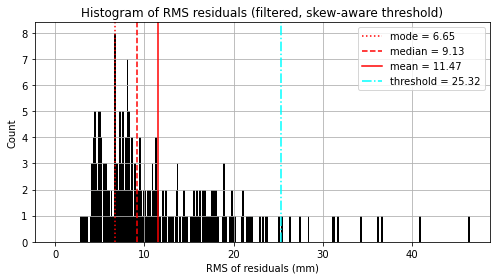

In [20]:
import numpy as np
import matplotlib.pyplot as plt

pairs = []
rms_values = []

with open(restxtfile, 'r') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = line.strip().split()
        if len(parts) >= 2:
            pairs.append(parts[0])
            rms_values.append(float(parts[1]))

rms_values = np.array(rms_values)
pairs = np.array(pairs)

# Remove zero-residual pairs before analysis
zero_mask = rms_values == 0.0
zero_pairs = pairs[zero_mask]

nonzero_mask = rms_values != 0.0
rms_values = rms_values[nonzero_mask]
pairs = pairs[nonzero_mask]
# Save zero-residuals before filtering


# Histogram-based mode (peak of histogram)
counts, bins = np.histogram(rms_values, bins=np.arange(0, np.max(rms_values) + 0.1, 0.1))
mode = bins[np.argmax(counts)] + 0.05

# Median and Mean
median = np.nanpercentile(rms_values, 50)
mean = np.nanmean(rms_values)

mean_rms = np.mean(rms_values)
std_rms = np.std(rms_values)
threshold = mean_rms + 2 * std_rms

# Find outliers
outlier_indices = np.where(rms_values > threshold)[0]
outlier_pairs = [pairs[i] for i in outlier_indices]
outlier_values = rms_values[outlier_indices]
all_problematic_pairs = list(outlier_pairs) + list(zero_pairs)
# Print summary and outliers
print(f"Mode:   {mode:.2f} mm")
print(f"Median: {median:.2f} mm")
print(f"Mean:   {mean:.2f} mm")
print(f"Threshold (skew-aware): {threshold:.2f} mm\n")

print("Outlier interferograms:")
for pair, rms in zip(outlier_pairs, outlier_values):
    print(f"{pair}: {rms:.2f} mm")

# Plot histogram
plt.figure(figsize=(7, 4))
plt.hist(rms_values, bins=np.arange(0, np.max(rms_values) + 0.1, 0.1), color='skyblue', edgecolor='black')

plt.axvline(mode, color='r', linestyle=':', label=f"mode = {mode:.2f}")
plt.axvline(median, color='r', linestyle='--', label=f"median = {median:.2f}")
plt.axvline(mean, color='r', linestyle='-', label=f"mean = {mean:.2f}")
plt.axvline(threshold, color='cyan', linestyle='-.', label=f"threshold = {threshold:.2f}")

plt.xlabel('RMS of residuals (mm)')
plt.ylabel('Count')
plt.title('Histogram of RMS residuals (filtered, skew-aware threshold)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [110]:
zero_pairs

array(['20230908_20231014', '20231002_20231014', '20230827_20230920'],
      dtype='<U17')

In [109]:
# Percentage of outliers
percent_outliers = 100 * len(all_problematic_pairs) / len(rms_values)
print(f"\nOutliers: {len(all_problematic_pairs)} / {len(rms_values)} interferograms "
      f"({percent_outliers:.1f}%) exceed the threshold.")


Outliers: 18 / 227 interferograms (7.9%) exceed the threshold.


In [95]:
from collections import Counter

# Example: outlier_pairs = ['20200101_20200113', '20200113_20200125', '20200101_20200125']
date_counter = Counter()

for pair in outlier_pairs:
    dates = pair.split('_')
    for date in dates:
        date_counter[date] += 1

# Print summary
print("Date occurrence in outlier pairs:")
for date, count in date_counter.most_common():
    print(f"{date}: {count} times")


Date occurrence in outlier pairs:
20240411: 8 times
20240330: 3 times
20240318: 3 times
20241008: 3 times
20240622: 2 times
20240610: 2 times
20240223: 1 times
20240306: 1 times
20240423: 1 times
20240505: 1 times
20240517: 1 times
20240529: 1 times
20240902: 1 times
20241113: 1 times
20241125: 1 times


In [51]:
resdir = '/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/sbois/post-3-060825/116A_05582_141515/TS_GEOCml10mask/13resid'
# Create the destination folder if it doesn't exist
problem_dir = os.path.join(resdir, 'problematic_resid')
os.makedirs(problem_dir, exist_ok=True)

# Loop and copy
for pair in outlier_pairs:
    print(f"Copying {pair}.res.png")
    src = os.path.join(resdir, f'{pair}.res.png')
    dst = os.path.join(problem_dir, f'{pair}.res.png')
    if os.path.exists(src):
        shutil.copy2(src, dst)
    else:
        print(f"Warning: {src} not found!")


Copying 20230312_20240318.res.png
Copying 20230324_20230628.res.png
Copying 20230312_20240330.res.png
Copying 20230324_20240306.res.png
Copying 20230324_20240318.res.png
Copying 20230324_20240330.res.png
Copying 20230604_20240306.res.png
Copying 20230616_20240306.res.png
Copying 20230604_20240330.res.png
Copying 20230405_20230429.res.png
Copying 20230616_20240318.res.png
Copying 20230604_20240610.res.png
Copying 20230616_20240610.res.png
Copying 20230312_20230628.res.png
Copying 20230604_20240622.res.png
Copying 20230628_20230710.res.png
Copying 20230616_20240622.res.png
Copying 20230312_20240306.res.png
Copying 20230628_20240622.res.png
Copying 20231119_20231225.res.png
Copying 20240223_20240330.res.png
Copying 20230628_20230803.res.png
Copying 20231107_20231119.res.png
Copying 20240223_20240411.res.png
Copying 20240306_20240330.res.png
Copying 20230628_20240306.res.png
Copying 20230628_20240318.res.png
Copying 20240306_20240411.res.png
Copying 20240211_20240330.res.png
Copying 202306

In [19]:
frame='014A_05232_242525'
restxtfile=f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/sbois/post-3/{frame}/TS_GEOCml10mask/info/13resid.txt'
resdir=f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/sbois/post-3/{frame}/TS_GEOCml10mask/13resid'
pairs = []
rms_values = []

with open(restxtfile, 'r') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        parts = line.strip().split()
        if len(parts) >= 2:
            pairs.append(parts[0])
            rms_values.append(float(parts[1]))

rms_values = np.array(rms_values)
pairs = np.array(pairs)




from datetime import datetime

def days_between(pair):
    try:
        d1_str, d2_str = pair.split('_')
        d1 = datetime.strptime(d1_str, '%Y%m%d')
        d2 = datetime.strptime(d2_str, '%Y%m%d')
        return abs((d2 - d1).days)
    except:
        return -1  # Malformed pair

# Extract pairs with exactly 60 days difference
sixty_day_indices = [i for i, pair in enumerate(pairs) if days_between(pair) >= 59]

# Print pairs and their RMS values
print("\nPairs with exactly 60 days separation and their residuals:")
for i in sixty_day_indices:
    print(f"{pairs[i]}: {rms_values[i]:.2f} mm")



Pairs with exactly 60 days separation and their residuals:
20230305_20240323: 17.33 mm
20230609_20230925: 19.55 mm
20230305_20230504: 10.34 mm
20230621_20230901: 12.05 mm
20230609_20240311: 17.91 mm
20230209_20230410: 18.91 mm
20230305_20230516: 11.71 mm
20230621_20230913: 14.77 mm
20230609_20240323: 21.90 mm
20230209_20230422: 16.96 mm
20230305_20230609: 16.70 mm
20230621_20230925: 25.31 mm
20230609_20240603: 20.13 mm
20230305_20230621: 18.12 mm
20230621_20240311: 28.33 mm
20230609_20240615: 17.62 mm
20230305_20230901: 13.58 mm
20230621_20240323: 23.50 mm
20230609_20240627: 23.60 mm
20230305_20230913: 16.13 mm
20230221_20230422: 13.10 mm
20230621_20240603: 21.41 mm
20230305_20230925: 18.89 mm
20230221_20230504: 16.18 mm
20230621_20240615: 17.49 mm
20230609_20230901: 11.08 mm
20230305_20240311: 17.94 mm
20230621_20240627: 18.27 mm
20230609_20230913: 11.21 mm
20230901_20240615: 17.01 mm
20230913_20240323: 19.07 mm
20230913_20240603: 19.96 mm
20230901_20240627: 25.00 mm
20230925_2024031

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

frames = [
    "014A_04920_161613", "021D_04972_131213", "043A_05008_161514", "050D_05246_131313",
    "087A_05101_131313", "094D_05100_131313", "116A_05207_252525", "123D_05095_141313",
    "014A_05232_242525", "021D_05266_252525", "043A_05221_121313", "050D_05443_121313",
    "087A_05317_121617", "094D_05288_130913", "116A_05367_141313", "123D_05292_242525",
    "014A_05540_151414", "021D_05566_131313", "043A_05421_141313", "087A_04904_121313",
    "094D_04913_101213", "116A_04978_131311", "116A_05582_141515", "123D_05489_131313"
]

def days_between(pair):
    try:
        d1_str, d2_str = pair.split('_')
        d1 = datetime.strptime(d1_str, '%Y%m%d')
        d2 = datetime.strptime(d2_str, '%Y%m%d')
        return abs((d2 - d1).days)
    except:
        return -1

for frame in frames:
    print(f"\n=== Frame: {frame} ===")
    
    restxtfile = f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/sbois/post-3/{frame}/TS_GEOCml10mask/info/13resid.txt'
    
    pairs = []
    rms_values = []
    
    with open(restxtfile, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) >= 2:
                pairs.append(parts[0])
                rms_values.append(float(parts[1]))
    
    pairs = np.array(pairs)
    rms_values = np.array(rms_values)
    
    # Identify and store zero-residuals
    zero_mask = np.array(rms_values) == 0.0
    zero_pairs = np.array(pairs)[zero_mask]

    
    # Remove zero-residuals
    mask = rms_values != 0.0
    pairs = pairs[mask]
    rms_values = rms_values[mask]
    
    # Compute stats
    counts, bins = np.histogram(rms_values, bins=np.arange(0, np.max(rms_values) + 0.1, 0.1))
    mode = bins[np.argmax(counts)] + 0.05
    median = np.nanpercentile(rms_values, 50)
    mean = np.nanmean(rms_values)
    threshold = mean + 2 * np.std(rms_values)
    
    print(f"Mode: {mode:.2f} mm | Median: {median:.2f} mm | Mean: {mean:.2f} mm | Threshold: {threshold:.2f} mm")
    
    # Outliers
    outlier_indices = np.where(rms_values > threshold)[0]
    # if len(outlier_indices) > 0:
    #     print("Outliers:")
    #     for i in outlier_indices:
    #         print(f"  {pairs[i]}: {rms_values[i]:.2f} mm")
    
    # Pairs with >=59 days
    sixty_day_indices = [i for i, pair in enumerate(pairs) if days_between(pair) >= 59]
    # if sixty_day_indices:
    #     print("Pairs with ≥59 days separation:")
    #     for i in sixty_day_indices:
    #         print(f"  {pairs[i]}: {rms_values[i]:.2f} mm")

    # # Zero-residual pairs
    # if len(zero_pairs) > 0:
    #     print("Zero-residual pairs (RMS = 0.0 mm):")
    #     for pair in zero_pairs:
    #         print(f"  {pair}")
        
    # # Histogram
    # plt.figure(figsize=(7, 4))
    # plt.hist(rms_values, bins=np.arange(0, np.max(rms_values) + 0.1, 0.1), color='skyblue', edgecolor='black')
    # plt.axvline(mode, color='r', linestyle=':', label=f"mode = {mode:.2f}")
    # plt.axvline(median, color='r', linestyle='--', label=f"median = {median:.2f}")
    # plt.axvline(mean, color='r', linestyle='-', label=f"mean = {mean:.2f}")
    # plt.axvline(threshold, color='cyan', linestyle='-.', label=f"threshold = {threshold:.2f}")
    # plt.xlabel('RMS of residuals (mm)')
    # plt.ylabel('Count')
    # plt.title(f'Histogram RMS residuals - {frame}')
    # plt.legend()
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()


    # Combine all problematic pairs
    all_problematic_pairs = set()

    # Add outlier pairs
    all_problematic_pairs.update(pairs[outlier_indices])

    # Add ≥59 day pairs
    all_problematic_pairs.update(pairs[sixty_day_indices])

    # Add zero residuals
    all_problematic_pairs.update(zero_pairs)

    if all_problematic_pairs:
        print("\nCombined problematic pairs (unique):")
        for pair in sorted(all_problematic_pairs):
            print(f"  {pair}")



=== Frame: 014A_04920_161613 ===
Mode: 5.75 mm | Median: 12.08 mm | Mean: 16.99 mm | Threshold: 42.21 mm

Combined problematic pairs (unique):
  20230209_20230410
  20230221_20230422
  20230305_20230504
  20230305_20230609
  20230305_20230621
  20230305_20230901
  20230305_20230913
  20230305_20230925
  20230305_20240311
  20230305_20240323
  20230317_20230516
  20230317_20230609
  20230317_20230621
  20230317_20230913
  20230317_20230925
  20230317_20240311
  20230317_20240323
  20230609_20230901
  20230609_20230913
  20230609_20230925
  20230609_20240311
  20230609_20240323
  20230609_20240603
  20230609_20240615
  20230609_20240627
  20230621_20230901
  20230621_20230925
  20230621_20240311
  20230621_20240323
  20230621_20240615
  20230621_20240627
  20230901_20240311
  20230901_20240323
  20230901_20240603
  20230901_20240615
  20230901_20240627
  20230901_20240919
  20230913_20240323
  20230913_20240615
  20230913_20240919
  20230925_20240311
  20230925_20240323
  20230925_20240